In [ ]:
def fetch_image_data():
    # TODO§
    return

In [ ]:
from pathlib import Path
import os

IMAGES_PATH = Path("../resources/cloud-images/CCSN_v2")

def index_labeled_images(images_path=IMAGES_PATH):
    cloud_labels = []
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images

    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            labeled_images[img_path.name] = {
                "label": cloud_dir.name,
                "path": str(img_path)
            }

    return labeled_images, cloud_labels

In [113]:
labeled_images, cloud_labels = index_labeled_images()

print(cloud_labels)

[PosixPath('../resources/cloud-images/CCSN_v2/Ac'), PosixPath('../resources/cloud-images/CCSN_v2/As'), PosixPath('../resources/cloud-images/CCSN_v2/Cb'), PosixPath('../resources/cloud-images/CCSN_v2/Cc'), PosixPath('../resources/cloud-images/CCSN_v2/Ci'), PosixPath('../resources/cloud-images/CCSN_v2/Cs'), PosixPath('../resources/cloud-images/CCSN_v2/Ct'), PosixPath('../resources/cloud-images/CCSN_v2/Cu'), PosixPath('../resources/cloud-images/CCSN_v2/Ns'), PosixPath('../resources/cloud-images/CCSN_v2/Sc'), PosixPath('../resources/cloud-images/CCSN_v2/St')]


In [93]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2

def extract_labels(labeled_images):
    images = []
    labels = []
    for (i, image_name) in enumerate(labeled_images):
        path = labeled_images[image_name]['path']
        image = cv2.imread(path)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image, (64, 64))
        images.append(image)

        label = labeled_images[image_name]['label']
        labels.append(label)

    return np.array(images), np.array(labels)

In [97]:
images, labels = extract_labels(labeled_images)

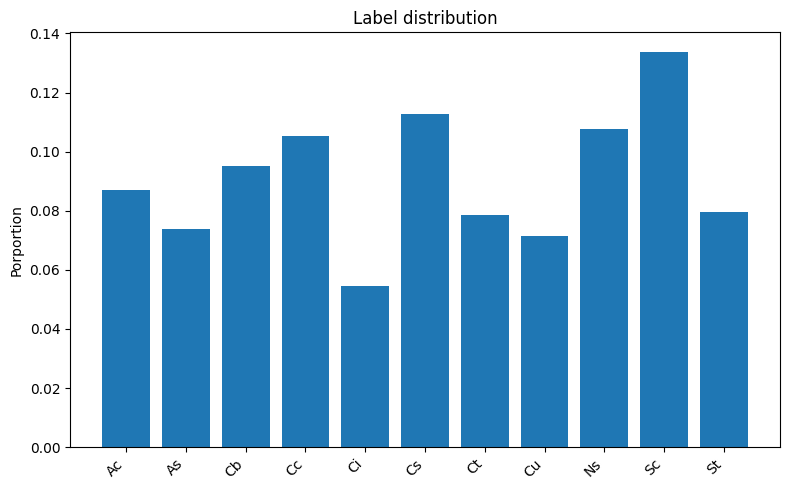

In [108]:
import matplotlib.pyplot as plt
from collections import Counter

# labels must be a 1D array or list of class names
label_counts = Counter(labels)
classes = list(label_counts.keys())
counts = np.array(list(label_counts.values()))
props = counts / counts.sum()

plt.figure(figsize=(8, 5))
plt.bar(classes, props)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Porportion")
plt.title("Label distribution")
plt.tight_layout()
plt.show()

In [128]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

ordinal_encoder = LabelEncoder()
labels_encoded = ordinal_encoder.fit_transform(labels)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(images, labels_encoded))

X_train, X_test = images[train_idx], images[test_idx]
y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)


train: (2034, 64, 64) (2034,)
test:  (509, 64, 64) (509,)
[ 8 10  3 ...  2 10  9]


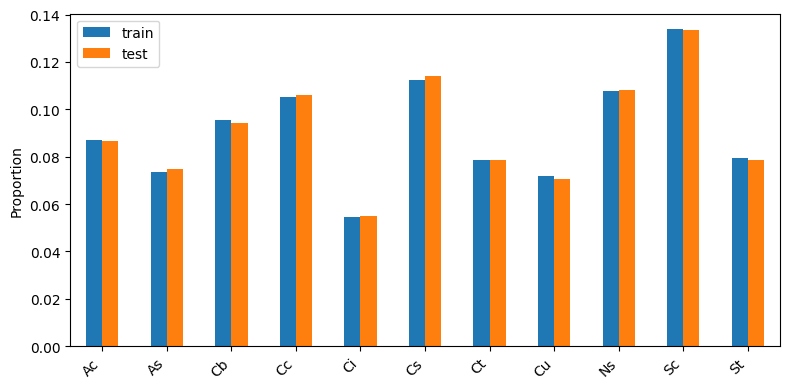

In [127]:
import pandas as pd
import matplotlib.pyplot as plt

train_props = pd.Series(ordinal_encoder.inverse_transform(y_train)).value_counts(normalize=True)
test_props  = pd.Series(ordinal_encoder.inverse_transform(y_test)).value_counts(normalize=True)

df = pd.DataFrame({"train": train_props, "test": test_props}).fillna(0).reindex(ordinal_encoder.classes_)

df.plot(kind="bar", figsize=(8,4))
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [130]:
from sklearn.linear_model import LogisticRegression

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

log_reg = LogisticRegression()
log_reg.fit(X_train_flat, y_train)


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [135]:
some_data = X_train_flat[:5]
some_labels = y_train[:5]

print("Predictions:", log_reg.predict(some_data))
print("Labels:", some_labels)

Predictions: [9 5 3 5 4]
Labels: [ 8 10  3  5  4]


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [136]:
from sklearn.metrics import mean_squared_error

cloud_predictions = log_reg.predict(X_train_flat)
log_mse = mean_squared_error(y_train, cloud_predictions)
log_rmse = np.sqrt(log_mse)

# is this useful in anyway since we're categorising things vs trying to calculate a value
log_rmse

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


np.float64(3.1223809083571394)

In [137]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(log_reg, X_train_flat, y_train, scoring="neg_mean_squared_error", cv=10)
log_rmse_scores = np.sqrt(-scores)

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength 

In [138]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [139]:
display_scores(log_rmse_scores)

Scores: [3.96800933 4.20084025 3.75604089 4.4363693  4.22168925 3.99753619
 4.13801314 4.00799693 4.18536036 4.11233876]
Mean: 4.102419438841848
Standard deviation: 0.1736776436296966


In [140]:
from sklearn.model_selection import cross_val_score

cross_val_score(log_reg, X_train_flat, y_train, scoring="accuracy", cv=5)

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength 

array([0.2014742 , 0.22358722, 0.19164619, 0.21867322, 0.18965517])

In [141]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(log_reg, X_train_flat, y_train, cv=3)

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength 

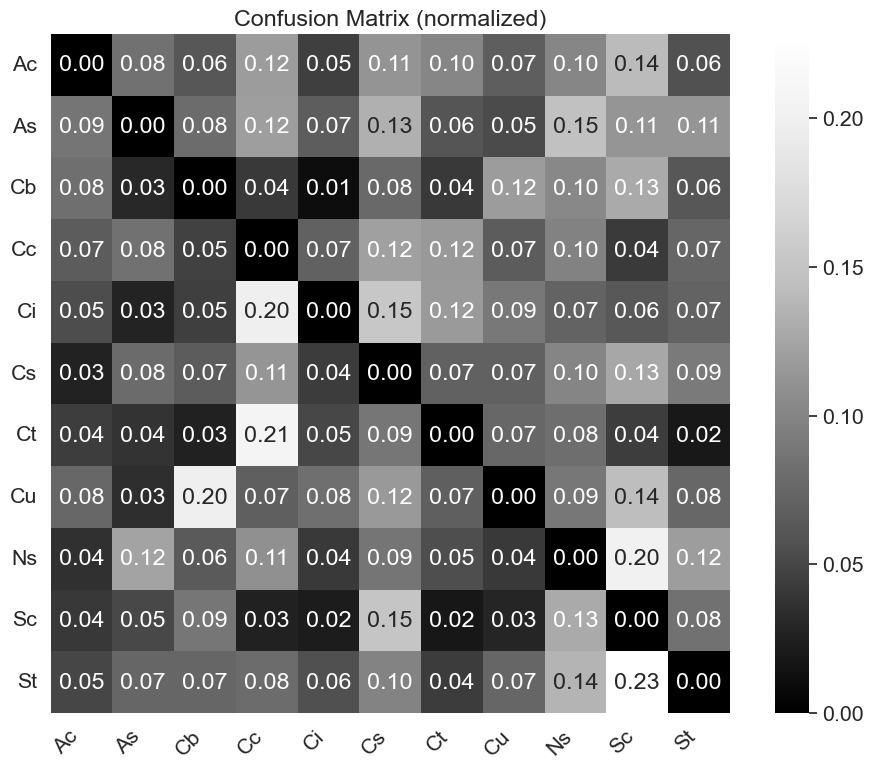

In [ ]:
# from sklearn.metrics import confusion_matrix
# conf_mx = confusion_matrix(y_train, y_train_pred)

# row_sums = conf_mx.sum(axis=1, keepdims=True)
# norm_conf_mx = conf_mx / row_sums
# np.fill_diagonal(norm_conf_mx, 0)
# plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
# plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# decode labels so matrix rows/cols use class names
y_true_names = ordinal_encoder.inverse_transform(y_train)
y_pred_names = ordinal_encoder.inverse_transform(y_train_pred)
conf_mx = confusion_matrix(y_true_names, y_pred_names, labels=ordinal_encoder.classes_)

# safe normalization
row_sums = conf_mx.sum(axis=1, keepdims=True)
with np.errstate(invalid='ignore', divide='ignore'):
    norm_conf_mx = np.divide(conf_mx, row_sums, where=row_sums!=0)
np.fill_diagonal(norm_conf_mx, 0)

df_cm = pd.DataFrame(norm_conf_mx, index=ordinal_encoder.classes_, columns=ordinal_encoder.classes_)

plt.figure(figsize=(10,8))
ax = sns.heatmap(
    df_cm,
    annot=True,
    fmt=".2f",
    cmap="Greys_r",
    cbar=True,
    linewidths=0,     # remove white separator lines
    linecolor=None,   # no line color
    square=True
)

# remove any axis grid/spines that can look like a grid
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("Confusion Matrix (normalized)")
plt.tight_layout()
plt.show()

In [150]:
# quick diagnostics
print("shapes:", images.shape if 'images' in globals() else None,
      labels.shape if 'labels' in globals() else None)
print("X_train shape:", X_train.shape if 'X_train' in globals() else None)
print("X_train_flat shape:", X_train_flat.shape if 'X_train_flat' in globals() else None)

import numpy as np
for name, arr in [('X_train_flat', globals().get('X_train_flat')),
                  ('X_test_flat', globals().get('X_test_flat'))]:
    if arr is None:
        print(name, "not defined")
    else:
        print(name, "dtype:", arr.dtype,
              "has NaN:", np.isnan(arr).any(),
              "has inf:", np.isinf(arr).any(),
              "min/max:", np.nanmin(arr), np.nanmax(arr))

# show a few label uniques
if 'y_train' in globals():
    print("y_train unique/counts:", np.unique(y_train, return_counts=True))

shapes: (2543, 64, 64) (2543,)
X_train shape: (2034, 64, 64)
X_train_flat shape: (2034, 4096)
X_train_flat dtype: uint8 has NaN: False has inf: False min/max: 0 255
X_test_flat dtype: uint8 has NaN: False has inf: False min/max: 0 255
y_train unique/counts: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([177, 150, 194, 214, 111, 229, 160, 146, 219, 272, 162]))


In [143]:
from sklearn.metrics import precision_score, recall_score, f1_score

def display_clf_scores(labels, predictions):
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)


In [ ]:
from typing import Dict, Any
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


def get_default_classifiers(random_state: int = 42) -> Dict[str, Any]:
    """
    Return a dictionary of main classification models (some with scaling).
    """
    return {
        "log_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=random_state))
        ]),
        "linear_svc": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(random_state=random_state))
        ]),
        "svc_rbf": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", probability=True, random_state=random_state))
        ]),
        "knn": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "decision_tree": DecisionTreeClassifier(random_state=random_state),
        "random_forest": RandomForestClassifier(random_state=random_state),
        "gradient_boosting": GradientBoostingClassifier(random_state=random_state),
        "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=random_state),
        "gaussian_nb": GaussianNB(),
        "mlp": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(max_iter=500, random_state=random_state))
        ])
    }


def evaluate_classifiers(X, y, scoring: str = "accuracy", cv: int = 5,
                         n_jobs: int = -1, random_state: int = 42,
                         verbose: int = 1
) -> pd.DataFrame:
    """
    Evaluate many classification models with default hyperparameters.
    Returns a sorted dataframe of cross-validation results.
    """
    classifiers = get_default_classifiers(random_state)
    cv_obj = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    results = []

    for name, clf in classifiers.items():
        if verbose:
            print(f"\nEvaluating model: {name}")

        scores = cross_val_score(
            clf, X, y,
            scoring=scoring,
            cv=cv_obj,
            n_jobs=n_jobs
        )

        results.append({
            "model": name,
            "mean_score": np.mean(scores),
            "std_score": np.std(scores)
        })

    return pd.DataFrame(results).sort_values("mean_score", ascending=False)


In [ ]:
results = evaluate_classifiers(X_train_flat, y_train, scoring="accuracy", cv=5)
print(results)



Evaluating model: log_reg


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely 


Evaluating model: linear_svc


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/lucasnseyep/code/LucasNseyep/belle-w


Evaluating model: svc_rbf

Evaluating model: knn

Evaluating model: decision_tree

Evaluating model: random_forest

Evaluating model: gradient_boosting
